# Know Your Noise — 01: Power Spectral Density & the PPSD

Authors:
* Thomas Lecocq, Royal Observatory of Belgium
* Koen Van Noten,  Royal Observatory of Belgium

**Goal**: Understand the Power Spectral Density (PSD) of seismic noise,
compute it with ObsPy's `PPSD` class, compare with the Peterson (1993) New
Low/High Noise Models (NLNM/NHNM), and build a probabilistic noise portrait
for a station.

**Prerequisites**: `obspy`, `numpy`, `matplotlib`

---
*Know Your Noise series — from ObsPy basics to advanced noise analysis*

## 1. Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from obspy import UTCDateTime, read, Stream
from obspy.clients.filesystem.sds import Client
from obspy.signal.spectral_estimation import PPSD, get_nlnm, get_nhnm
from obspy import read, read_inventory

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Data configuration


In [2]:
SDS_ROOT = "/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS"
RESPONSES = "/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/stationxml"


NETWORK  = "XG"
STATION  = "BB01"
LOCATION = ""
CHANNEL  = "HHZ"

# One full day — more data → better statistics in the PPSD
T0 = UTCDateTime("2024-03-20T00:00:00")
T1 = T0 + 86400          # 24 hours

print(f"Request window: {T0}  →  {T1}")

Request window: 2024-03-20T00:00:00.000000Z  →  2024-03-21T00:00:00.000000Z


## 3. Fetch data and inventory

In [3]:
client = Client(SDS_ROOT)

inv = read_inventory(os.path.join(RESPONSES, "*"))

st = client.get_waveforms(
    network=NETWORK, station=STATION,
    location=LOCATION, channel=CHANNEL,
    starttime=T0, endtime=T1,
)
st.merge(method=1, fill_value="interpolate")   # merge gaps
print(st)

1 Trace(s) in Stream:
XG.BB01..HHZ | 2024-03-20T00:00:00.000000Z - 2024-03-21T00:00:00.000000Z | 200.0 Hz, 17280001 samples


## 4. Build the PPSD

The `PPSD` class implements the **Peterson (1993)** method:
- Splits the trace into overlapping 1-hour segments (by default)
- Computes the PSD of each segment after instrument-response removal
- Accumulates a 2-D histogram: period × power (dB)

Key parameters:
| Parameter | Default | Effect |
|-----------|---------|--------|
| `ppsd_length` | 3600 s | Length of each PSD segment |
| `overlap`     | 0.5    | Fractional overlap between segments |
| `period_smoothing_width_octaves` | 1.0 | Smoothing in period domain |
| `period_step_octaves` | 0.0125 | Step size in period domain |
| `db_bins`     | (-200, -50, 0.5) | dB histogram bins |

In [4]:
# PPSD parameters: let's start with default parameters
PPSD_LENGTH = 3600
PPSD_OVERLAP = 0.5
PERIOD_SMOOTHING_WIDTH_OCTAVES = 1.0
PERIOD_STEP_OCTAVES = 0.125

ppsd = PPSD(
    st[0].stats,
    metadata=inv,
    ppsd_length=PPSD_LENGTH,
    overlap=PPSD_OVERLAP,
    period_smoothing_width_octaves=PERIOD_SMOOTHING_WIDTH_OCTAVES,
    period_step_octaves=PERIOD_STEP_OCTAVES,
    db_bins=(-200, -50, 0.5),
)

ppsd.add(st)

print(f"\nPPSD computed over {len(ppsd.current_times_used)} segment(s).")
print(f"Period range: {ppsd.period_bin_centers[0]:.3f} – {ppsd.period_bin_centers[-1]:.1f} s")
print(f"Freq range  : {1/ppsd.period_bin_centers[-1]:.4f} – {1/ppsd.period_bin_centers[0]:.1f} Hz")


PPSD computed over 47 segment(s).
Period range: 0.010 – 655.4 s
Freq range  : 0.0015 – 100.0 Hz


## 5. Peterson NLNM / NHNM

As said above, Peterson (1993) defined empirical bounds from globally distributed quiet and
noisy stations. Any well-installed broadband station should have PSDs between
these bounds (the lowest possible, actually)

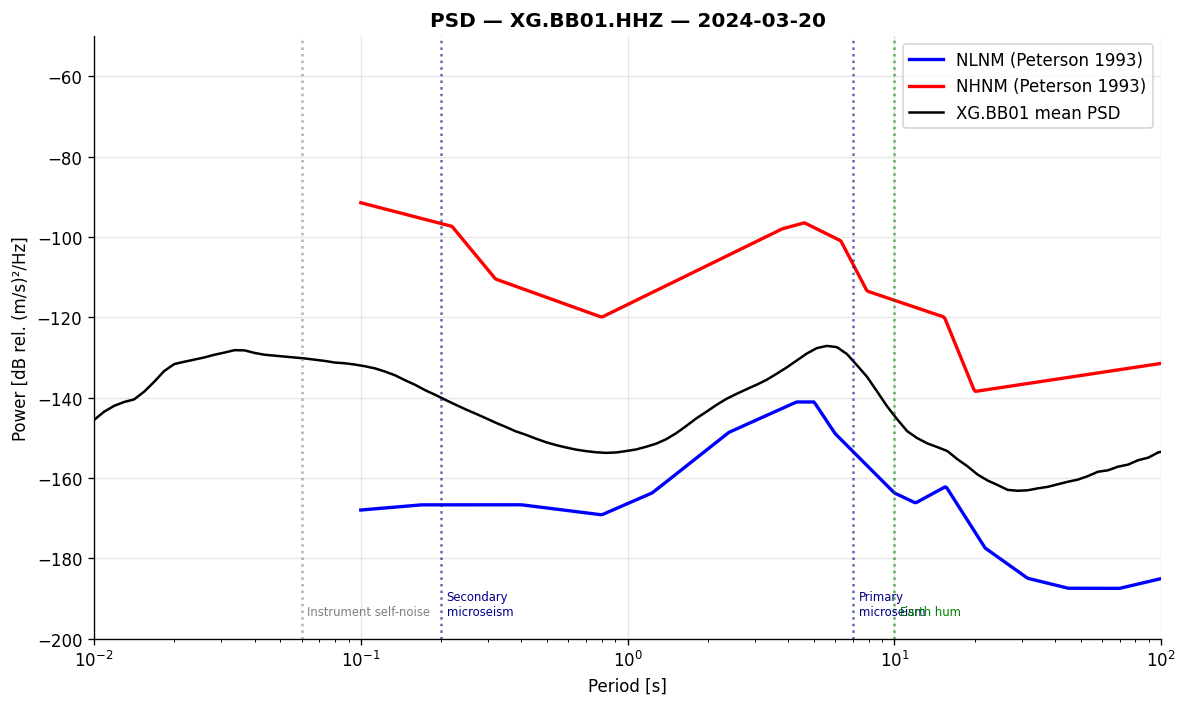

In [5]:
per_nlnm, pow_nlnm = get_nlnm()
per_nhnm, pow_nhnm = get_nhnm()

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(per_nlnm, pow_nlnm, "b-", lw=2, label="NLNM (Peterson 1993)")
ax.semilogx(per_nhnm, pow_nhnm, "r-", lw=2, label="NHNM (Peterson 1993)")

# Overlay mean PSD from our PPSD
periods, mean_psd = ppsd.get_mean()
ax.semilogx(periods, mean_psd, "k-", lw=1.5, label=f"{NETWORK}.{STATION} mean PSD")

ax.set_xlim(0.01, 100)
ax.set_ylim(-200, -50)
ax.set_xlabel("Period [s]")
ax.set_ylabel("Power [dB rel. (m/s)²/Hz]")
ax.set_title(f"PSD — {NETWORK}.{STATION}.{CHANNEL} — {T0.strftime('%Y-%m-%d')}", fontweight="bold")
ax.legend()
# ax.invert_xaxis()

# Annotate key noise bands
for period, label, color in [
    (0.06,   "Instrument self-noise", "gray"),
    (0.2,    "Secondary\nmicroseism", "darkblue"),
    (7.0,    "Primary\nmicroseism", "navy"),
    (10.0,   "Earth hum", "green"),
]:
    ax.axvline(period, color=color, ls=":", alpha=0.6)
    ax.text(period * 1.05, -195, label, color=color, fontsize=7, va="bottom")

plt.tight_layout()
plt.show()

## 6. Probabilistic PSD plot (ObsPy built-in)

The PPSD histogram shows the **probability density** of observing a given
power level at each period. This is more informative than a single-trace PSD
because it reveals the full variability.

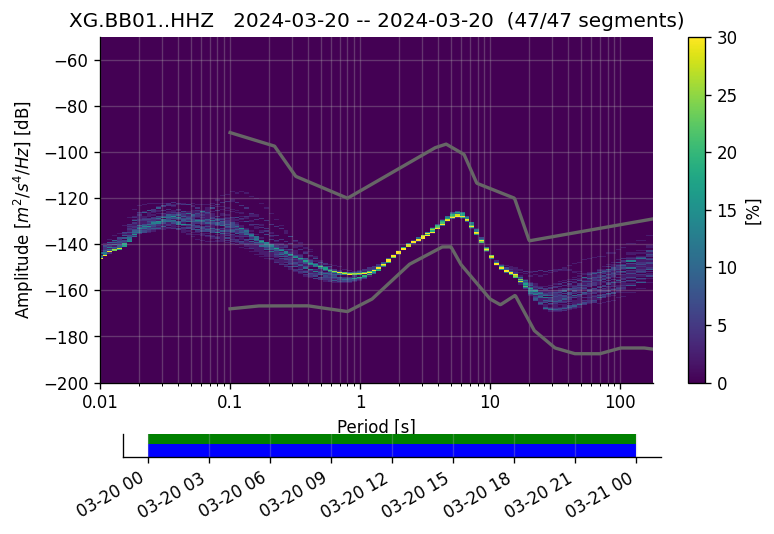

In [6]:
ppsd.plot()

### 🔍 What do we see on this PPSD?

The default `ppsd.plot()` produces a **probabilistic power spectral density** (PPSD) plot — a 2-D histogram where:

- **X-axis** → Period (seconds), shown on a log scale
- **Y-axis** → Power spectral density (dB relative to (m/s)²/Hz)
- **Colour scale** → Probability of occurrence (how often a given power level is observed at each period)

The two reference curves overlaid are the **Peterson (1993) noise models**:
| Curve | Meaning |
|-------|---------|
| **NLNM** (New Low-Noise Model) | Lower bound — the quietest sites on Earth |
| **NHNM** (New High-Noise Model) | Upper bound — the noisiest acceptable station |


With only **47 segments from a single day**, the colour histogram may look sparse — more data (weeks/months) produces a much smoother probability distribution.

---

### ⚙️ Suggestions to tweak `ppsd.plot()` parameters

```
# 1️⃣  Restrict the period range to the sensor's useful band
ppsd.plot(period_lim=(0.01, 100))

# 2️⃣  Show percentile lines (e.g. 10th, 50th, 90th) on top of the histogram
ppsd.plot(show_percentiles=True, percentiles=[10, 50, 90])

# 3️⃣  Show the temporal coverage bar at the top
ppsd.plot(show_coverage=True)

# 4️⃣  Change the colour map for better contrast
ppsd.plot(cmap=obspy.imaging.cm.pqlx)   # classic PQLX colours
# or use any Matplotlib colourmap:
ppsd.plot(cmap="viridis")

# 5️⃣  Disable the histogram and show only the noise models + percentiles
ppsd.plot(show_histogram=False, show_percentiles=True)

# 6️⃣  Combine several options at once
ppsd.plot(
    show_coverage=True,
    show_histogram=True,
    show_percentiles=True,
    percentiles=[5, 10, 50, 90, 95],
    show_noise_models=True,
    grid=True,
    period_lim=(0.01, 100)
)
```

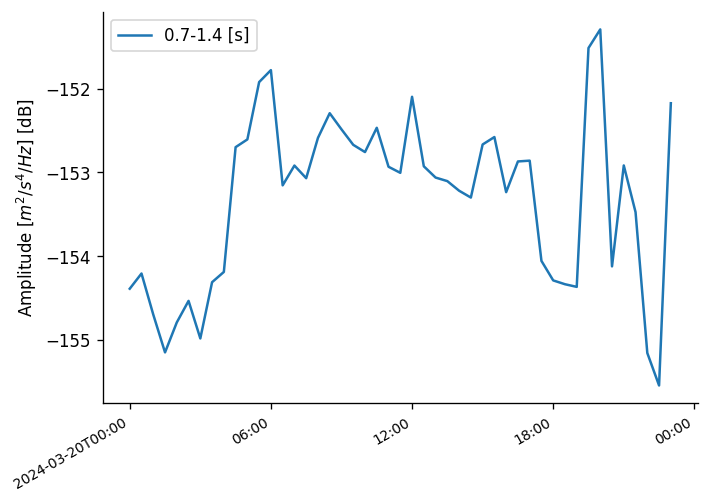

In [7]:
ppsd.plot_temporal(period=1.0, show=False);

In [8]:
# Exercise: try some of the 1️⃣ to 6️⃣ suggestions from above here:

ppsd.plot(......

SyntaxError: '(' was never closed (1221906016.py, line 3)

## 7. Extract and plot percentile curves manually

Accessing the raw percentile arrays lets you overlay them on custom figures
or compare multiple stations.

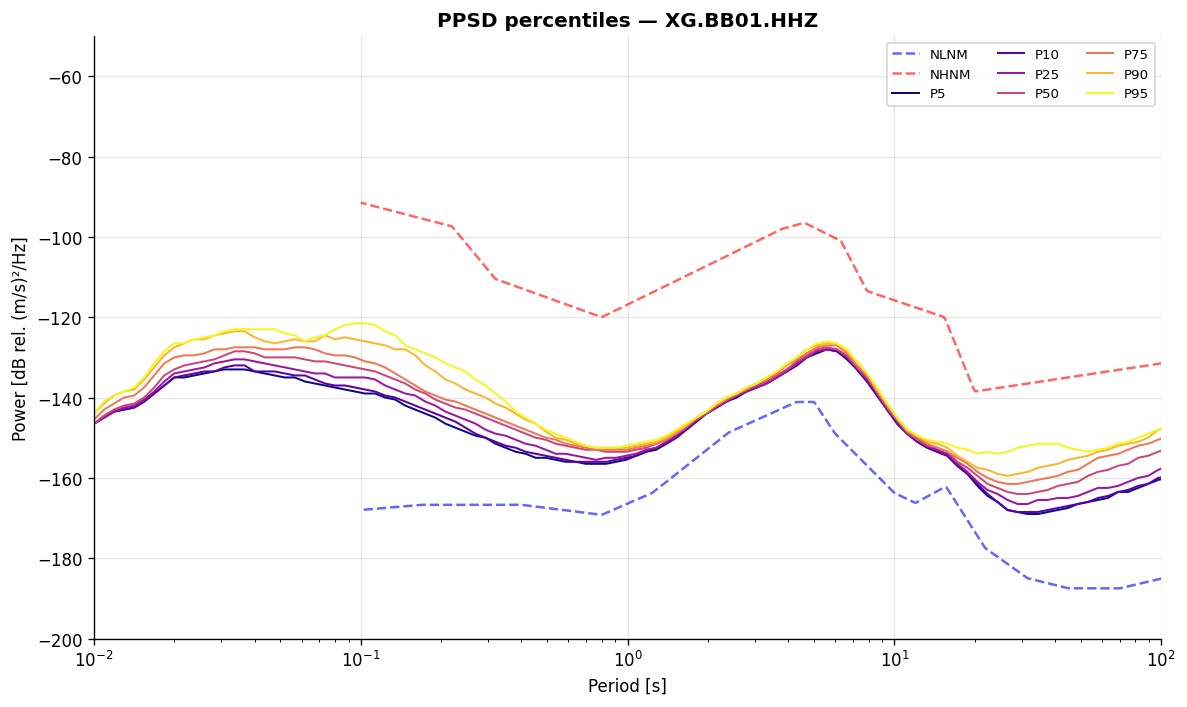

In [ ]:
percentiles_to_plot = [5, 10, 25, 50, 75, 90, 95]
pct_values = ppsd.get_percentile(percentile=50)  # median as baseline check

fig, ax = plt.subplots(figsize=(10, 6))

# Peterson models
ax.semilogx(per_nlnm, pow_nlnm, "b--", lw=1.5, alpha=0.6, label="NLNM")
ax.semilogx(per_nhnm, pow_nhnm, "r--", lw=1.5, alpha=0.6, label="NHNM")

cmap = plt.get_cmap("plasma", len(percentiles_to_plot))
for i, p in enumerate(percentiles_to_plot):
    periods, pct_arr = ppsd.get_percentile(percentile=p)
    if pct_arr is not None:
        ax.semilogx(periods, pct_arr, color=cmap(i), lw=1.2, label=f"P{p}")

ax.set_xlim(0.01, 100)
ax.set_ylim(-200, -50)
ax.set_xlabel("Period [s]")
ax.set_ylabel("Power [dB rel. (m/s)²/Hz]")
ax.set_title(f"PPSD percentiles — {NETWORK}.{STATION}.{CHANNEL}", fontweight="bold")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

## 8. Temporal stacking: day vs. night

The HARD way (to manually loop over segments)

In [ ]:
# Identify day (07–21 UTC) and night (21–07 UTC) segments
import datetime

day_psds, night_psds = [], []

for t_used, psd_row in zip(ppsd.current_times_used, ppsd.psd_values):
    hour = t_used.hour
    if 7 <= hour < 21:
        day_psds.append(psd_row)
    else:
        night_psds.append(psd_row)

day_psds   = np.array(day_psds, dtype=float)
night_psds = np.array(night_psds, dtype=float)

print(f"Day segments  : {len(day_psds)}")
print(f"Night segments: {len(night_psds)}")

Day segments  : 28
Night segments: 19


### 8.1 Plot day/night comparison

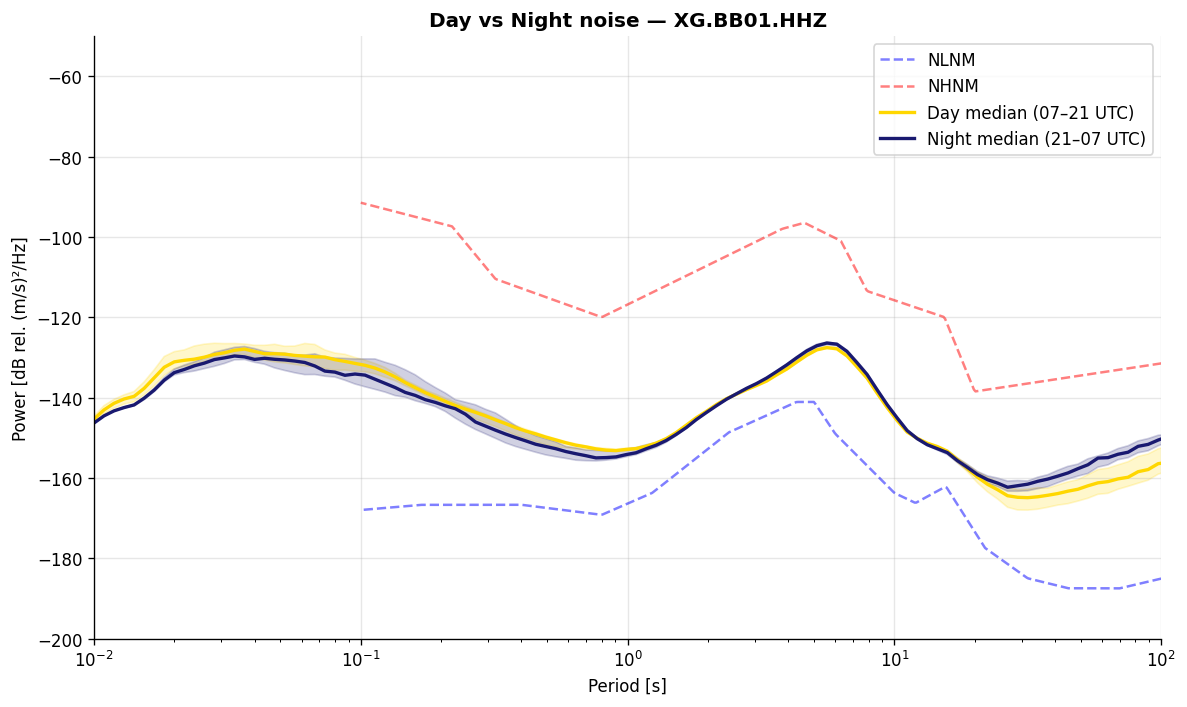

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogx(per_nlnm, pow_nlnm, "b--", lw=1.5, alpha=0.5, label="NLNM")
ax.semilogx(per_nhnm, pow_nhnm, "r--", lw=1.5, alpha=0.5, label="NHNM")

# Replace -inf from empty bins with NaN before taking median
def safe_median(arr):
    a = arr.copy().astype(float)
    a[a <= -200] = np.nan
    return np.nanmedian(a, axis=0)

if len(day_psds) > 0:
    ax.semilogx(periods, safe_median(day_psds),   "gold",     lw=2, label="Day median (07–21 UTC)")
    ax.fill_between(
        periods,
        np.nanpercentile(day_psds, 25, axis=0),
        np.nanpercentile(day_psds, 75, axis=0),
        color="gold", alpha=0.2,
    )

if len(night_psds) > 0:
    ax.semilogx(periods, safe_median(night_psds), "midnightblue", lw=2, label="Night median (21–07 UTC)")
    ax.fill_between(
        periods,
        np.nanpercentile(night_psds, 25, axis=0),
        np.nanpercentile(night_psds, 75, axis=0),
        color="midnightblue", alpha=0.2,
    )

ax.set_xlim(0.01, 100)
ax.set_ylim(-200, -50)
ax.set_xlabel("Period [s]")
ax.set_ylabel("Power [dB rel. (m/s)²/Hz]")
ax.set_title(f"Day vs Night noise — {NETWORK}.{STATION}.{CHANNEL}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

> **Observation**: At high frequencies (> 1 Hz), daytime PSDs are consistently
> higher than nighttime — signature of cultural noise (traffic, industry).
> At 5–10 s period, the microseismic peak is **continuous** and insensitive to
> time of day, confirming its oceanic origin.

## 8b. Temporal stacking: day vs. night (using ObsPy's built-in time selection)

Instead of manually looping over segments, we can use
`ppsd.calculate_histogram(time_of_weekday=...)` to restrict which PSD segments
are included in the histogram **before** calling `ppsd.plot()`.

The `time_of_weekday` parameter takes a list of tuples:
`(weekday, start_hour, end_hour)` — where **weekday = -1** means "any day of the week".

Day segments used: 29


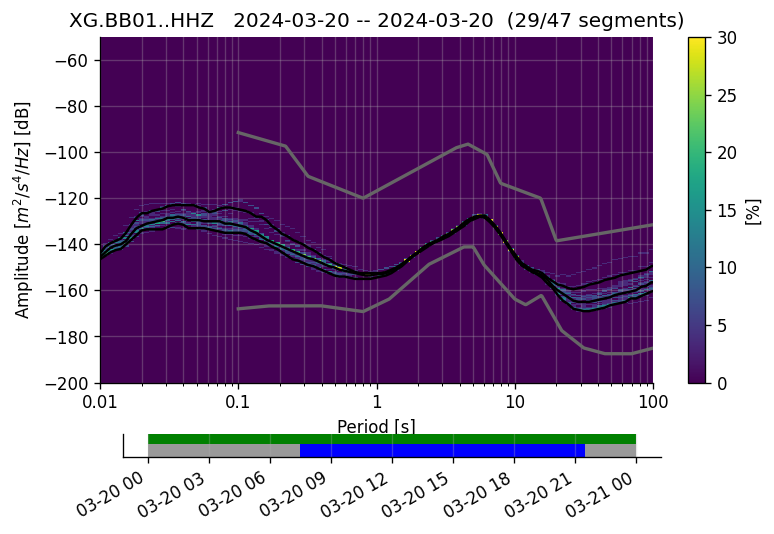

Night segments used: 20


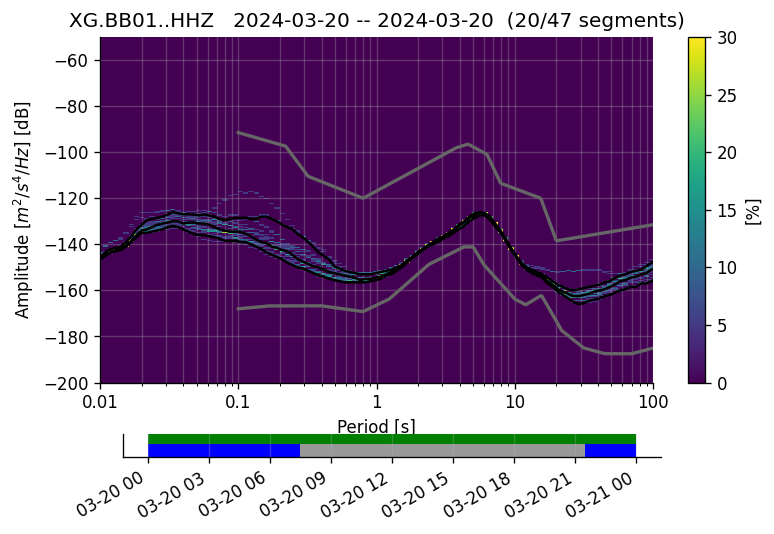

In [ ]:
# ── Daytime PPSD (07–21 UTC, all days) ──
ppsd.calculate_histogram(time_of_weekday=[(-1, 7, 21)])
print(f"Day segments used: {len(ppsd.current_times_used)}")
ppsd.plot(
    show_percentiles=True,
    percentiles=[10, 50, 90],
    show_noise_models=True,
    period_lim=(0.01, 100),
)

# ── Nighttime PPSD (21–07 UTC, all days) ──
# Note: wrap around midnight by providing TWO tuples
ppsd.calculate_histogram(time_of_weekday=[(-1, 21, 24), (-1, 0, 7)])
print(f"Night segments used: {len(ppsd.current_times_used)}")
ppsd.plot(
    show_percentiles=True,
    percentiles=[10, 50, 90],
    show_noise_models=True,
    period_lim=(0.01, 100),
)

# ── Reset to full histogram (all times) ──
ppsd.calculate_histogram()

### 8.1 Overlay day vs. night median curves

Even with the built-in selection, we can extract percentile curves from each
time slice and overlay them on a custom figure for direct comparison.


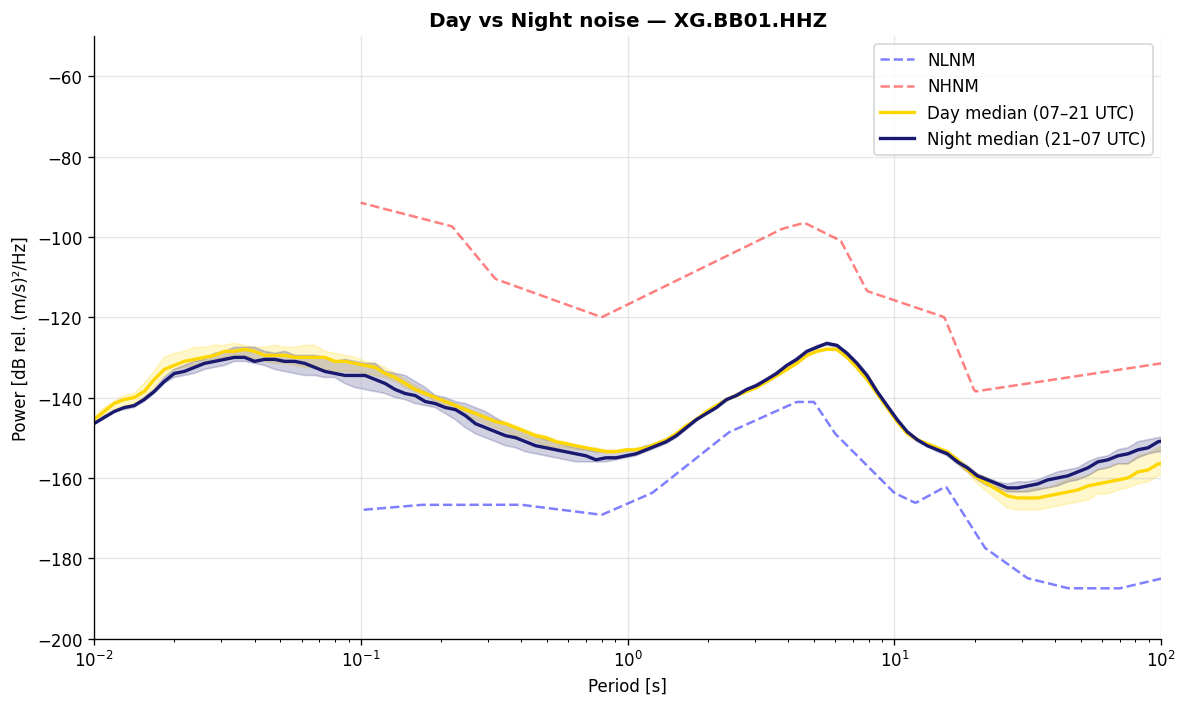

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Peterson models
ax.semilogx(per_nlnm, pow_nlnm, "b--", lw=1.5, alpha=0.5, label="NLNM")
ax.semilogx(per_nhnm, pow_nhnm, "r--", lw=1.5, alpha=0.5, label="NHNM")

# Day
ppsd.calculate_histogram(time_of_weekday=[(-1, 7, 21)])
periods_day, pct_day_50 = ppsd.get_percentile(percentile=50)
_, pct_day_25 = ppsd.get_percentile(percentile=25)
_, pct_day_75 = ppsd.get_percentile(percentile=75)
ax.semilogx(periods_day, pct_day_50, "gold", lw=2, label="Day median (07–21 UTC)")
ax.fill_between(periods_day, pct_day_25, pct_day_75, color="gold", alpha=0.2)

# Night
ppsd.calculate_histogram(time_of_weekday=[(-1, 21, 24), (-1, 0, 7)])
periods_night, pct_night_50 = ppsd.get_percentile(percentile=50)
_, pct_night_25 = ppsd.get_percentile(percentile=25)
_, pct_night_75 = ppsd.get_percentile(percentile=75)
ax.semilogx(periods_night, pct_night_50, "midnightblue", lw=2, label="Night median (21–07 UTC)")
ax.fill_between(periods_night, pct_night_25, pct_night_75, color="midnightblue", alpha=0.2)

# Reset histogram to full data
ppsd.calculate_histogram()

ax.set_xlim(0.01, 100)
ax.set_ylim(-200, -50)
ax.set_xlabel("Period [s]")
ax.set_ylabel("Power [dB rel. (m/s)²/Hz]")
ax.set_title(f"Day vs Night noise — {NETWORK}.{STATION}.{CHANNEL}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Load more data into the PPSD for better statistics

With only 1 day (~47 segments) the day/night split is thin. Let's feed **4 days**
of data into the existing `ppsd` object — `ppsd.add()` is cumulative, so it will
skip any segments it already has and only add the new ones.

In [ ]:
# ── Extend PPSD to 4 full days (2024-03-20 → 2024-03-24) ──
from obspy import UTCDateTime

start = UTCDateTime("2024-03-20")
ndays = 4

for day_offset in range(ndays):
    day_start = start + day_offset * 86400
    day_end = day_start + 86400

    st_day = client.get_waveforms(
        network=NETWORK, station=STATION,
        location=LOCATION, channel=CHANNEL,
        starttime=day_start, endtime=day_end,
    )
    st_day.merge(method=1, fill_value="interpolate")

    if len(st_day) > 0:
        ppsd.add(st_day)
        print(f"  Added {day_start.date}  →  total segments: {len(ppsd.current_times_used)}")
    else:
        print(f"  No data for {day_start.date}")

print(f"\nPPSD now contains {len(ppsd.current_times_used)} segment(s) "
      f"spanning {ppsd.current_times_used[0].date} → {ppsd.current_times_used[-1].date}")

/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/.venv/lib/python3.12/site-packages/obspy/signal/spectral_estimation.py:984: UserWarning: Already covered time spans detected (e.g. 2024-03-20T00:00:00.000000Z), skipping these slices.
  warnings.warn(msg)
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/.venv/lib/python3.12/site-packages/obspy/signal/spectral_estimation.py:984: UserWarning: Already covered time spans detected (e.g. 2024-03-20T00:30:00.000000Z), skipping these slices.
  warnings.warn(msg)
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/.venv/lib/python3.12/site-packages/obspy/signal/spectral_estimation.py:984: UserWarning: Already covered time spans detected (e.g. 2024-03-20T01:00:00.000000Z), skipping these slices.
  warnings.warn(msg)
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSe

  Added 2024-03-20  →  total segments: 47
  Added 2024-03-21  →  total segments: 94
  Added 2024-03-22  →  total segments: 141
  No data for 2024-03-23

PPSD now contains 141 segment(s) spanning 2024-03-20 → 2024-03-22


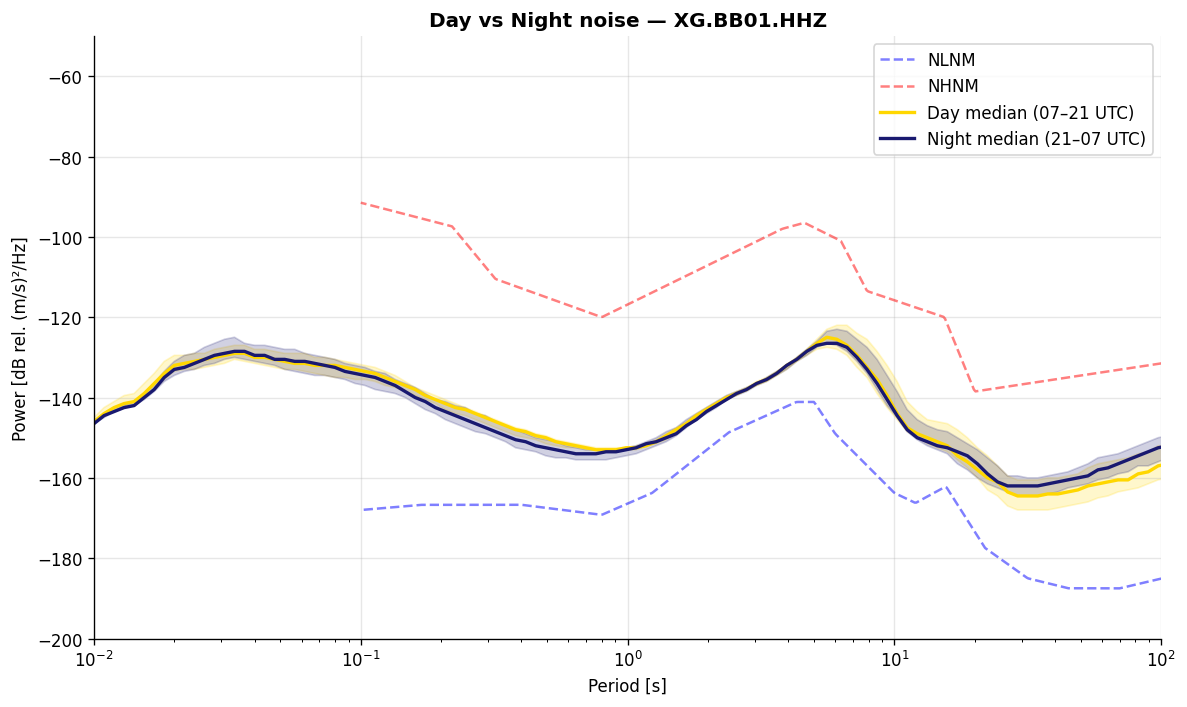

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Peterson models
ax.semilogx(per_nlnm, pow_nlnm, "b--", lw=1.5, alpha=0.5, label="NLNM")
ax.semilogx(per_nhnm, pow_nhnm, "r--", lw=1.5, alpha=0.5, label="NHNM")

# Day
ppsd.calculate_histogram(time_of_weekday=[(-1, 7, 21)])
periods_day, pct_day_50 = ppsd.get_percentile(percentile=50)
_, pct_day_25 = ppsd.get_percentile(percentile=25)
_, pct_day_75 = ppsd.get_percentile(percentile=75)
ax.semilogx(periods_day, pct_day_50, "gold", lw=2, label="Day median (07–21 UTC)")
ax.fill_between(periods_day, pct_day_25, pct_day_75, color="gold", alpha=0.2)

# Night
ppsd.calculate_histogram(time_of_weekday=[(-1, 21, 24), (-1, 0, 7)])
periods_night, pct_night_50 = ppsd.get_percentile(percentile=50)
_, pct_night_25 = ppsd.get_percentile(percentile=25)
_, pct_night_75 = ppsd.get_percentile(percentile=75)
ax.semilogx(periods_night, pct_night_50, "midnightblue", lw=2, label="Night median (21–07 UTC)")
ax.fill_between(periods_night, pct_night_25, pct_night_75, color="midnightblue", alpha=0.2)

# Reset histogram to full data
ppsd.calculate_histogram()

ax.set_xlim(0.01, 100)
ax.set_ylim(-200, -50)
ax.set_xlabel("Period [s]")
ax.set_ylabel("Power [dB rel. (m/s)²/Hz]")
ax.set_title(f"Day vs Night noise — {NETWORK}.{STATION}.{CHANNEL}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 8b. PSD Spectrogram — noise evolution over time

A PPSD histogram collapses time into a probability distribution. A **spectrogram**
of the PSDs keeps the time axis, showing how the power at each period evolves
segment by segment. This is ideal for spotting:

- **Day/night cycles** in cultural noise (high-frequency)
- **Storm arrivals** driving the microseismic peak
- **Transient events** (earthquakes, blasts, installation work)

/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/.venv/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/.venv/lib/python3.12/site-packages/obspy/signal/spectral_estimation.py:1709: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.tight_layout()
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/.venv/lib/python3.12/site-packages/obspy/signal/spectral_estimation.py:

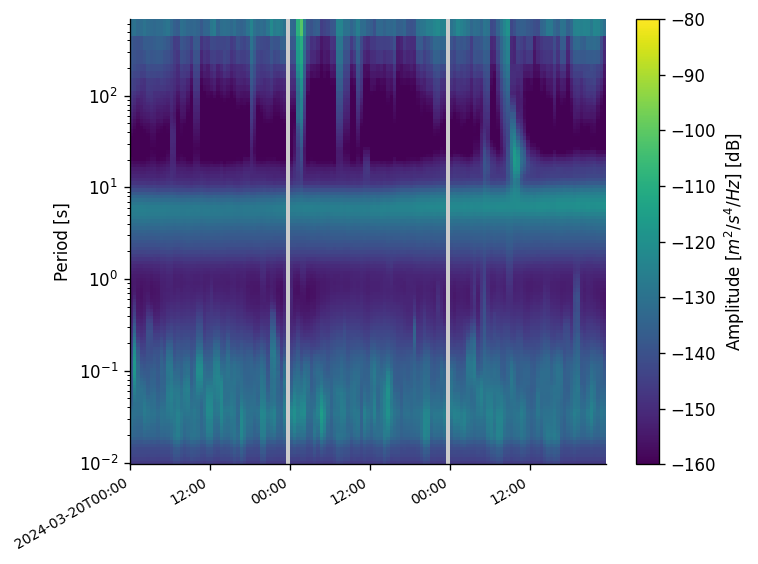

In [ ]:
# First, the ObsPy way
ppsd.calculate_histogram()
ppsd.plot_spectrogram(clim=(-160,-80))

PPSD reset — 141 segments, 2024-03-20 → 2024-03-22
Colour scale: vmin=-154.3 dB  (P2)  —  vmax=-122.9 dB  (P98)


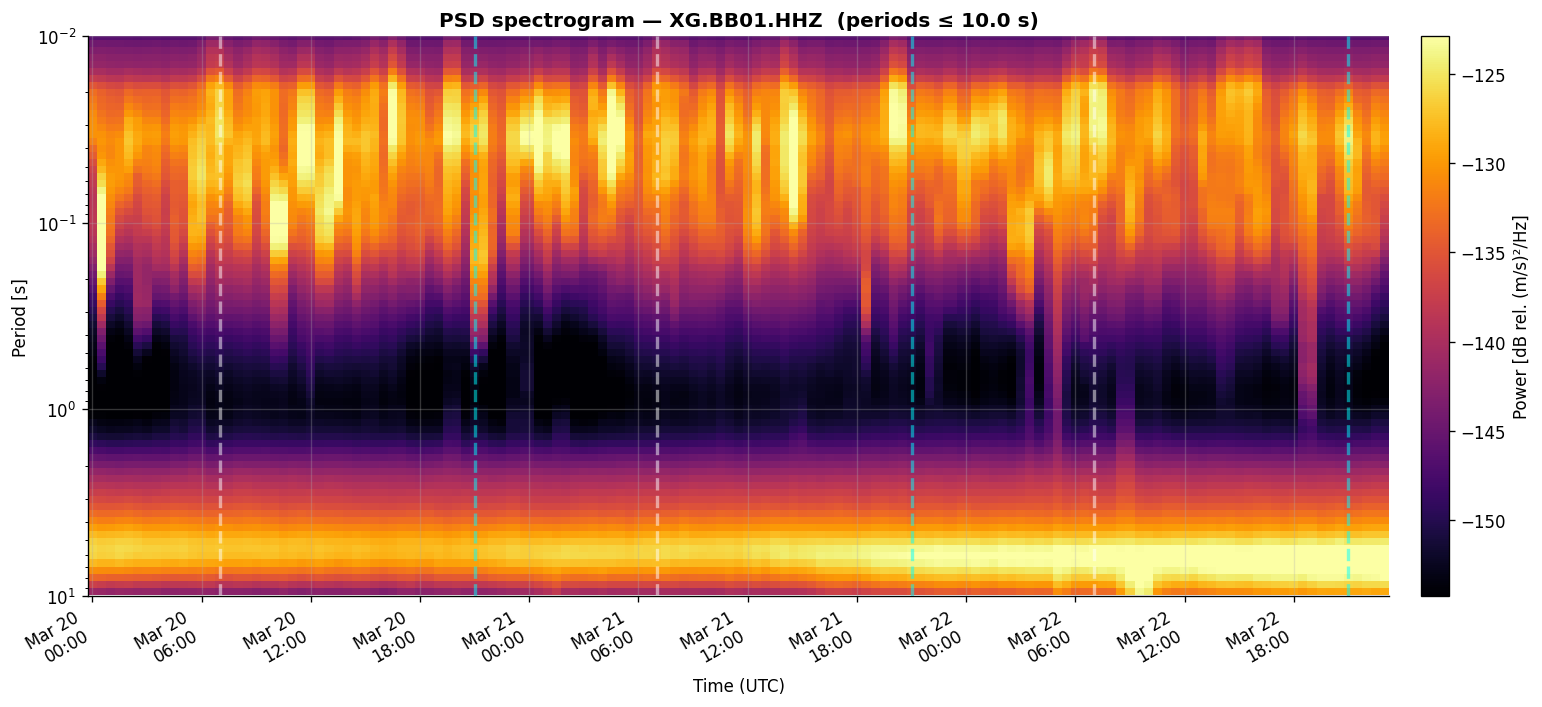

In [ ]:
# ── Reset histogram to full dataset ──
ppsd.calculate_histogram()
print(f"PPSD reset — {len(ppsd.current_times_used)} segments, "
      f"{ppsd.current_times_used[0].date} → {ppsd.current_times_used[-1].date}")

# ── Build the spectrogram matrix (time × period) ──
import matplotlib.dates as mdates

MAX_PERIOD = 10.0  # seconds — above this the sensor self-noise dominates

times = np.array([t.matplotlib_date for t in ppsd.current_times_used])
psd_matrix = np.array(ppsd.psd_values, dtype=float)
periods = ppsd.period_bin_centers

# Mask out periods above the cutoff
period_mask = periods > MAX_PERIOD
psd_matrix[:, period_mask] = np.nan

# ── Derive vmin / vmax from the remaining valid data ──
valid = psd_matrix[~np.isnan(psd_matrix)]
vmin = np.percentile(valid, 2)
vmax = np.percentile(valid, 98)
print(f"Colour scale: vmin={vmin:.1f} dB  (P2)  —  vmax={vmax:.1f} dB  (P98)")

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.pcolormesh(
    times, periods, psd_matrix.T,
    shading="nearest",
    cmap="inferno",
    vmin=vmin, vmax=vmax,
)
ax.set_yscale("log")
ax.set_ylim(0.01, MAX_PERIOD)
ax.invert_yaxis()
ax.set_ylabel("Period [s]")
ax.set_xlabel("Time (UTC)")
ax.set_title(
    f"PSD spectrogram — {NETWORK}.{STATION}.{CHANNEL}  (periods ≤ {MAX_PERIOD} s)",
    fontweight="bold",
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
fig.autofmt_xdate()

cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label("Power [dB rel. (m/s)²/Hz]")

# Mark day/night transitions
for t in ppsd.current_times_used:
    if t.hour == 7 and t.minute == 0:
        ax.axvline(t.matplotlib_date, color="white", ls="--", lw=2.0, alpha=0.5)
    elif t.hour == 21 and t.minute == 0:
        ax.axvline(t.matplotlib_date, color="cyan", ls="--", lw=2.0, alpha=0.5)

plt.tight_layout()
plt.show()

## 9. Temporal noise evolution: `plot_temporal` & multi-period "pseudo-RMS"

`ppsd.plot_temporal(period=T)` extracts the PSD value at a **single period** `T`
for every time segment and plots it as a time-series. This is essentially a
**"pseudo-RMS"** proxy — a measure of how the noise power at a given frequency
band evolves over time.

By picking **several characteristic periods** we can track different noise sources
simultaneously:

| Period | Frequency | Typical source |
|--------|-----------|----------------|
| 0.05 s | 20 Hz | High-frequency cultural noise, machinery |
| 0.2 s  | 5 Hz  | Secondary microseism / anthropogenic |
| 1.0 s  | 1 Hz  | Secondary microseism (ocean swell interaction) |
| 5.0 s  | 0.2 Hz | Primary microseism (ocean swell) |


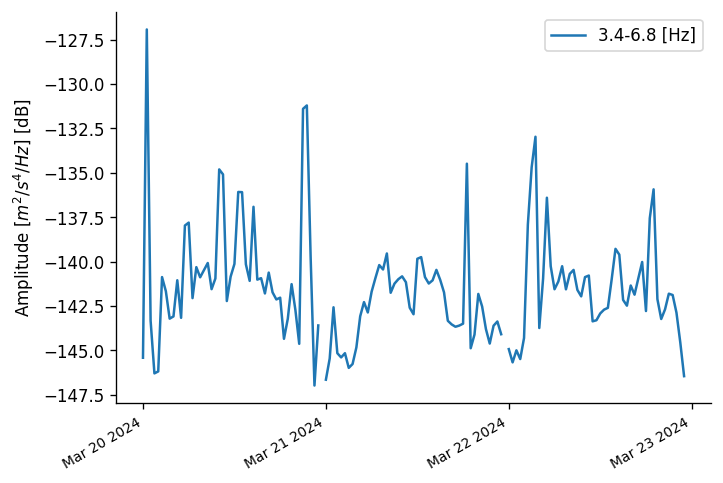

In [ ]:
# ── Simple: ObsPy's built-in temporal plot for a single period ──
ppsd.calculate_histogram()   # make sure we're using all data

ppsd.plot_temporal(period=0.2, show=True)

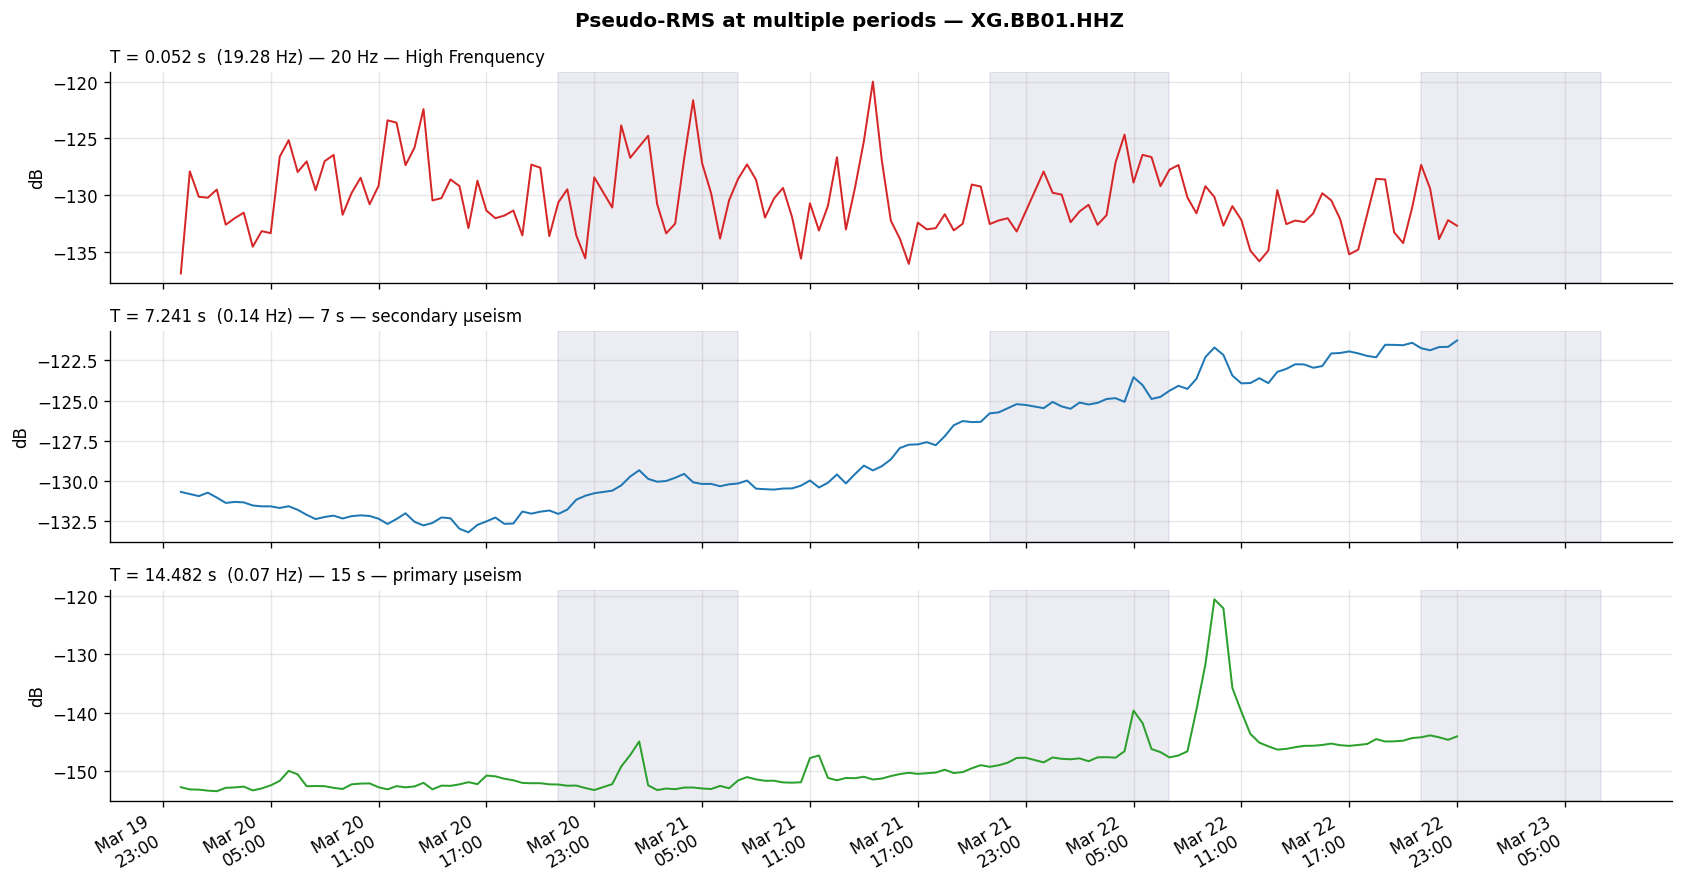

In [ ]:
# ── Advanced: overlay multiple periods on a single figure ──
import matplotlib.dates as mdates

ppsd.calculate_histogram()  # reset to all data

# Periods to monitor (pick what's relevant for your site!)
monitor_periods = {
    0.05: ("20 Hz — High Frenquency", "tab:red"),
    7.0: ("7 s — secondary µseism", "tab:blue"),
    15.0: ("15 s — primary µseism", "tab:green"),
}

# Extract PSD values at each target period
times_mpl = np.array([t.matplotlib_date for t in ppsd.current_times_used])
all_periods = ppsd.period_bin_centers
psd_values = np.array(ppsd.psd_values)

fig, axes = plt.subplots(len(monitor_periods), 1,
                         figsize=(14, 2.5 * len(monitor_periods)),
                         sharex=True)

for ax, (target_period, (label, color)) in zip(axes, monitor_periods.items()):
    # Find the closest period bin
    idx = np.argmin(np.abs(all_periods - target_period))
    actual_period = all_periods[idx]

    psd_at_period = psd_values[:, idx]

    ax.plot(times_mpl, psd_at_period, color=color, lw=1.2)
    ax.set_ylabel("dB")
    ax.set_title(f"T = {actual_period:.3f} s  ({1 / actual_period:.2f} Hz) — {label}",
                 fontsize=10, loc="left")
    ax.grid(True, alpha=0.3)

    # Shade night hours (21–07 UTC)
    for t in ppsd.current_times_used:
        if t.hour == 21 and t.minute == 0:
            night_start = t.matplotlib_date
            night_end = night_start + 10 / 24  # ~10 hours
            ax.axvspan(night_start, night_end,
                       color="midnightblue", alpha=0.08)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=6))
fig.autofmt_xdate()

fig.suptitle(f"Pseudo-RMS at multiple periods — {NETWORK}.{STATION}.{CHANNEL}",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

## Saving and reloading a PPSD

PPSD objects can be serialised to NPZ files. This is essential for long-term
monitoring workflows where you accumulate data over months/years.

In [ ]:
PPSD_FILE = f"./{NETWORK}.{STATION}.{LOCATION}.{CHANNEL}.npz"
ppsd.save_npz(PPSD_FILE)
print(f"PPSD saved to {PPSD_FILE}")

# Reload
ppsd_loaded = PPSD.load_npz(PPSD_FILE)
print(f"Reloaded PPSD — {len(ppsd_loaded.current_times_used)} segment(s)")

PPSD saved to ./XG.BB01..HHZ.npz
Reloaded PPSD — 141 segment(s)


## Let's change some parameters and re-run the analysis

Let's play:

- Change the STATION code used
- Change the CHANNEL for the same STATION
- or change the PPSD parameters (see below)

### Why reduce the smoothing? McNamara & Buland vs. fine-resolution PSDs

#### The defaults — designed for long-term monitoring

ObsPy's `PPSD` ships with defaults that **reproduce McNamara & Buland (2004)**:

| Parameter | Default | Meaning |
|-----------|---------|---------|
| `period_smoothing_width_octaves` | **1.0** | Each PSD bin averages power over a **full octave** in period |
| `period_step_octaves` | **0.125** | Bins are spaced every ⅛ octave |

This heavy smoothing was chosen deliberately: it produces **stable, comparable**
noise portraits across stations and over long time spans. The NLNM/NHNM
reference models were built with these conventions, so matching them makes your
PPSD directly comparable to the Peterson (1993) curves.

### The problem — smoothing hides narrow spectral peaks

A 1-octave-wide smoothing window spans a **factor of 2 in period** (e.g.
0.5–1.0 s, or 1–2 Hz). Any noise source that is **narrower** than this gets
*averaged together with its neighbours* and its true amplitude is diluted.

**Real-world examples of narrow peaks:**

| Source | Typical frequency | Bandwidth |
|--------|------------------|-----------|
| Rotating machinery (fans, pumps) | 25, 50, 100 Hz (harmonics) | < 1 Hz wide |
| Power-line hum (EU) | 50 Hz + harmonics | ~0.1 Hz wide |
| Wind-turbine infrasound | 1–4 Hz | ~0.5 Hz wide |
| Traffic on a bridge | 2–15 Hz (resonance) | ~1–2 Hz wide |
| Building resonance / tilt | 0.5–2 Hz | < 0.5 Hz wide |
| Primary microseism | 15-17 seconds | 5 seconds wide |

With the default 1-octave smoothing, a sharp 50 Hz power-line spike gets smeared
across the 35–70 Hz band. Its **peak amplitude drops** by many dB in the PPSD,
and it looks like a broad, moderate hump rather than the razor-thin line it
actually is. Yet that single tone may be the dominant contributor to your
high-frequency noise level!

### The fix — less smoothing, finer steps

try to re-run this notebook from the top with these parameters: (you can also duplicate the notebook to compare the results)
```python
PPSD_LENGTH = 3600
PPSD_OVERLAP = 0.5
PERIOD_SMOOTHING_WIDTH_OCTAVES = 0.125
PERIOD_STEP_OCTAVES = 0.0125
```